# Cuaderno 2: Imágenes en color y canales

En este cuaderno vas a trabajar con una idea fundamental: una imagen color no es un bloque indivisible, sino una combinación de canales. Entender eso vuelve mucho más claro por qué a veces los colores se ven mal y cómo podemos analizarlos por separado.

## Objetivos

- Distinguir entre los formatos `BGR` y `RGB`.
- Separar los canales de color de una imagen.
- Interpretar visualmente qué aporta cada canal.
- Empezar a relacionar color, intensidad y estructura de datos.


In [5]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen RGB")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


In [3]:
ruta = Path("frutos_rojos.png")
url = "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1"

if not ruta.exists():
    urllib.request.urlretrieve(url, ruta)

print("Imagen lista para trabajar.")


Imagen lista para trabajar.


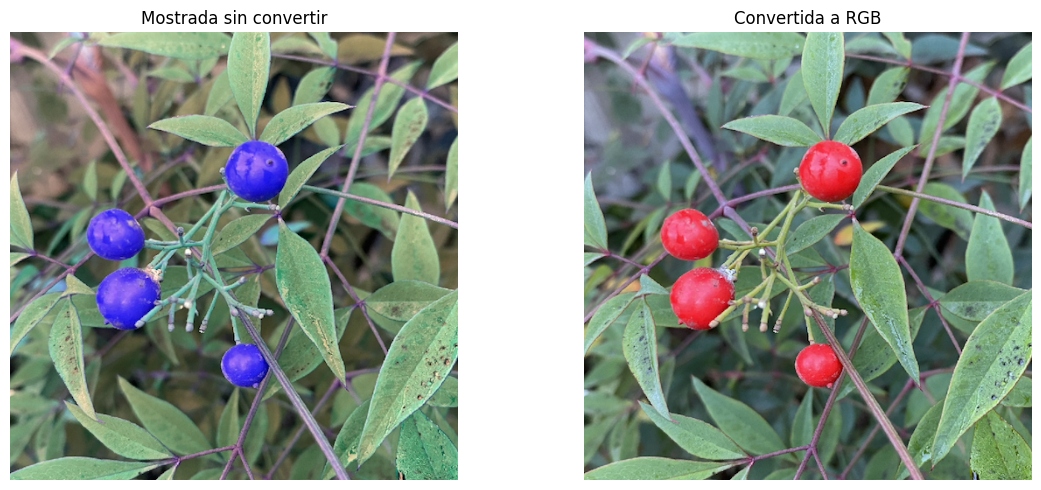

Forma de la imagen: (512, 512, 3)
OpenCV lee en formato BGR. Matplotlib espera RGB.


In [4]:
imagen_bgr = cv2.imread(str(ruta))
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(imagen_bgr)
axes[0].set_title("Mostrada sin convertir")
axes[0].axis("off")

axes[1].imshow(imagen_rgb)
axes[1].set_title("Convertida a RGB")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Forma de la imagen: {imagen_bgr.shape}")
print("OpenCV lee en formato BGR. Matplotlib espera RGB.")


## Idea central

Cuando la imagen se muestra "mal" no significa que el archivo esté roto. Lo que ocurre es que cada biblioteca interpreta en distinto orden los canales de color.

- En `OpenCV`, el orden por defecto es `BGR`.
- En `Matplotlib`, el orden esperado es `RGB`.

Por eso, antes de analizar colores, conviene verificar con qué formato estamos trabajando.


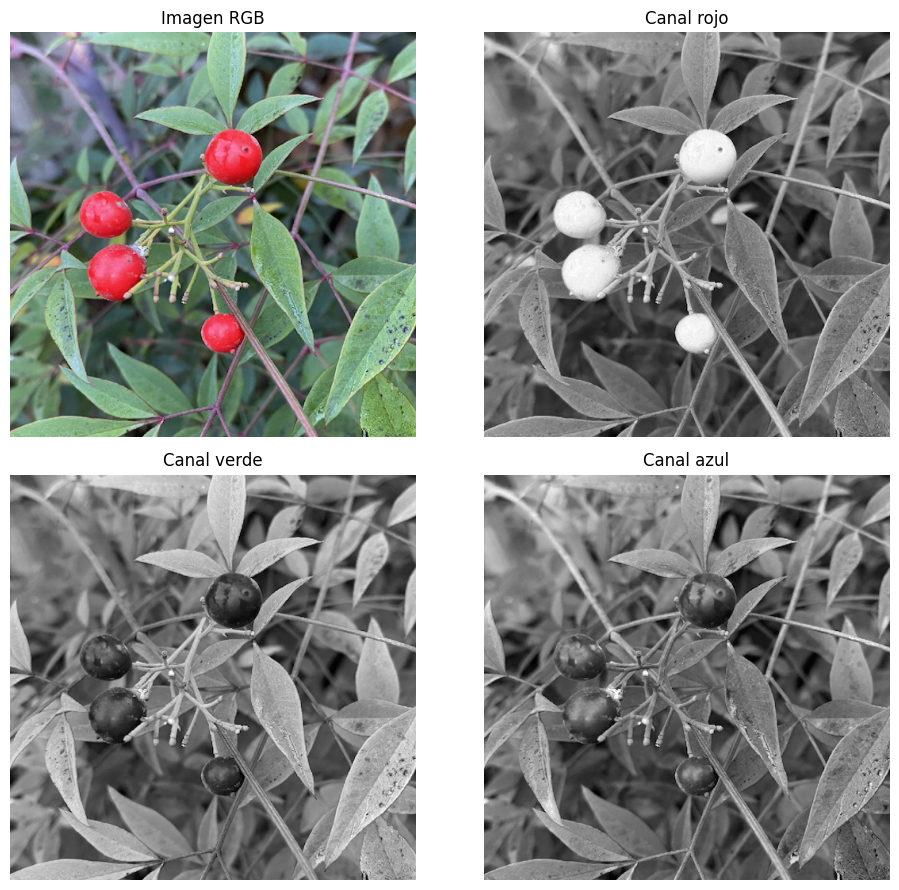

In [6]:
mostrar_canales(imagen_rgb)


## Para interpretar

Observá estas preguntas antes de seguir:

- ¿En qué canal se ven más brillantes los frutos?
- ¿En cuál se destacan más las hojas?
- ¿Qué significa que un objeto se vea claro u oscuro en un canal?

Un canal claro indica que ese color tiene mucha presencia en esa zona. Un canal oscuro indica lo contrario.


Primer píxel leído con OpenCV y convertido a RGB: [82 88 88]
Primer píxel leído con Matplotlib: [0.32156864 0.34509805 0.34509805 1.        ]


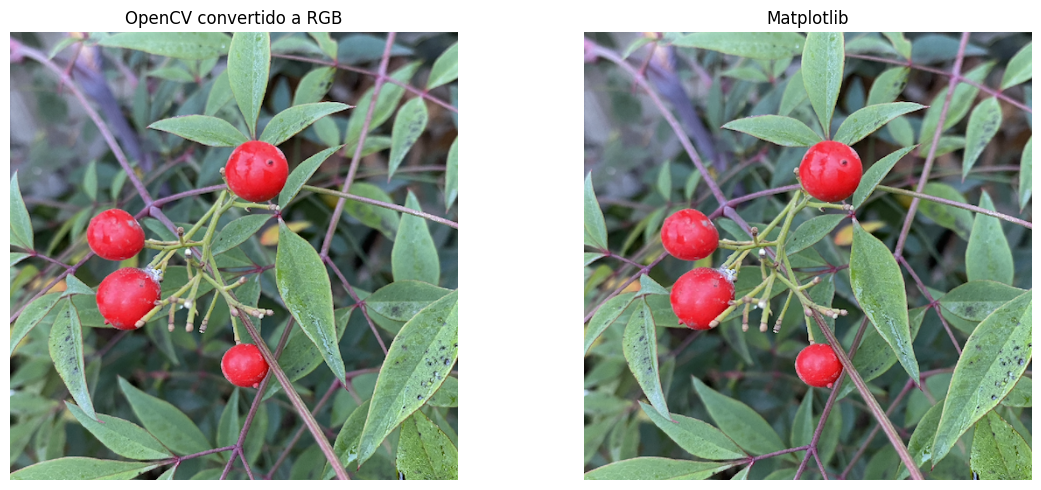

In [7]:
imagen_matplotlib = plt.imread(ruta)

print("Primer píxel leído con OpenCV y convertido a RGB:", imagen_rgb[0, 0])
print("Primer píxel leído con Matplotlib:", imagen_matplotlib[0, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("OpenCV convertido a RGB")
axes[0].axis("off")

axes[1].imshow(imagen_matplotlib)
axes[1].set_title("Matplotlib")
axes[1].axis("off")

plt.tight_layout()
plt.show()


## Cierre

En este cuaderno viste que una imagen color puede desarmarse en tres matrices: rojo, verde y azul. Esa idea aparece una y otra vez en procesamiento digital de imágenes porque permite analizar, comparar y segmentar información visual con más precisión.

En el próximo cuaderno vas a usar `OpenCV` para aplicar operaciones básicas sobre imágenes.
